<a href="https://colab.research.google.com/github/Abhishek-Prashant-Chandurkar/EPR_BUJSO/blob/main/Equal_Partitioning_Rule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Equal Partitioning Rule (EPR) - Simplified Implementation

This notebook:
- Generates synthetic dataset
- Implements Equal Partitioning Rule (EPR)
- Computes metrics (Makespan, Cost, Risk)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

## Generate Synthetic Dataset

In [ ]:
num_tasks = 100
num_vms = 10

tasks = pd.DataFrame({
    "task_id": range(num_tasks),
    "task_size": np.random.randint(100, 1000, num_tasks),  # Large/Small task in terms of resources
    "execution_time": np.random.randint(10, 100, num_tasks),
    "security": np.random.uniform(0, 2, num_tasks) # Higher score lower risk
})

vms = pd.DataFrame({
    "vm_id": range(num_vms),
    "capacity": np.random.randint(500, 2000, num_vms),  # This is what task size consumes
    "cost_per_unit": np.random.uniform(0.5, 2.0, num_vms)
})

tasks.head(), vms.head()

(   task_id  task_size  execution_time  security
 0        0        202              81  1.021495
 1        1        535              87  0.834822
 2        2        960              96  0.444216
 3        3        370              71  0.239731
 4        4        206              49  0.675230,
    vm_id  capacity  cost_per_unit
 0      0      1806       1.583678
 1      1       526       0.921159
 2      2       725       0.536474
 3      3      1800       1.468208
 4      4      1297       0.765666)

In [ ]:

# Parameters
num_tasks = 100
num_vms = 10
np.random.seed(42)

# 1. Average Case: Random distribution (Baseline)
exec_times_avg = np.random.randint(10, 100, num_tasks)

# 2. Worst Case: Sorted distribution (Maximum imbalance for sequential partitioning)
exec_times_worst = np.sort(np.random.randint(10, 100, num_tasks))

# 3. Best Case: Homogeneous distribution (Perfectly uniform tasks)
# Using 55 as it is the approximate mean of the random interval [10, 100)
exec_times_best = np.full(num_tasks, 55)

# Function to generate task DataFrame
def generate_tasks_df(execution_times):
    return pd.DataFrame({
        "task_id": range(num_tasks),
        "task_size": np.random.randint(100, 1000, num_tasks),
        "execution_time": execution_times,
        "security": np.random.uniform(0, 2, num_tasks)
    })

# Generate DataFrames
tasks_avg = generate_tasks_df(exec_times_avg)
tasks_worst = generate_tasks_df(exec_times_worst)
tasks_best = generate_tasks_df(exec_times_best)



## Equal Partitioning Rule (EPR)

In [ ]:
def equal_partitioning(tasks, num_vms):
    allocation = {}
    tasks_per_vm = len(tasks) // num_vms
    task_ids = tasks['task_id'].tolist()

    for i in range(num_vms):
        allocation[i] = task_ids[i*tasks_per_vm:(i+1)*tasks_per_vm]

    return allocation

allocation_avg = equal_partitioning(tasks_avg, num_vms)
allocation_worst = equal_partitioning(tasks_worst, num_vms)
allocation_best = equal_partitioning(tasks_best, num_vms)



## Metrics Calculation

In [ ]:
def calculate_makespan(allocation, tasks):
    vm_times = [tasks[tasks.task_id.isin(v)]['execution_time'].sum() for v in allocation.values()]
    return max(vm_times)

def calculate_utilization_cost(allocation, tasks, vms):
    total = 0
    for vm, t in allocation.items():
        total += tasks[tasks.task_id.isin(t)]['task_size'].sum() * vms.loc[vm, 'cost_per_unit']
    return total

def calculate_migration_cost(allocation):
    return sum(len(v) for v in allocation.values()) * 0.1

def calculate_risk(tasks):
    return np.mean([1 - np.exp(-1.5*s) if s <= 1 else 1 - np.exp(-0.5*s) for s in tasks['security']])

makespan = calculate_makespan(allocation_avg, tasks)
util_cost = calculate_utilization_cost(allocation_avg, tasks, vms)
migration_cost = calculate_migration_cost(allocation_avg)
risk = calculate_risk(tasks)

makespan, util_cost, migration_cost, risk

(np.int64(753),
 np.float64(65440.72287844617),
 10.0,
 np.float64(0.4871417845185937))

## Visualization

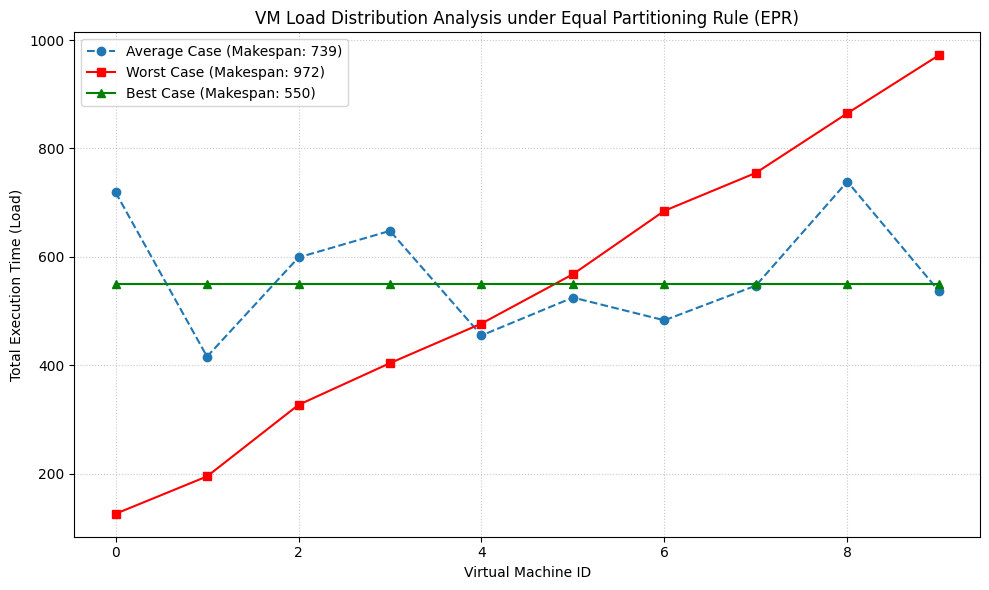

In [ ]:
# Calculate VM Loads
def calculate_vm_loads(allocation, tasks_df):
    return [tasks_df[tasks_df.task_id.isin(v)]['execution_time'].sum() for v in allocation.values()]

load_avg = calculate_vm_loads(allocation_avg, tasks_avg)
load_worst = calculate_vm_loads(allocation_worst, tasks_worst)
load_best = calculate_vm_loads(allocation_best, tasks_best)

# Visualization
plt.figure(figsize=(10, 6))

plt.plot(range(num_vms), load_avg, marker='o', label=f'Average Case (Makespan: {max(load_avg)})', linestyle='--')
plt.plot(range(num_vms), load_worst, marker='s', label=f'Worst Case (Makespan: {max(load_worst)})', color='red')
plt.plot(range(num_vms), load_best, marker='^', label=f'Best Case (Makespan: {max(load_best)})', color='green')

plt.title('VM Load Distribution Analysis under Equal Partitioning Rule (EPR)')
plt.xlabel('Virtual Machine ID')
plt.ylabel('Total Execution Time (Load)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()